<a href="https://colab.research.google.com/github/Naren203/Machine-Learning-/blob/main/LAB_EXAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

you are  a dara scientist at urbanIQ Analytics, a company that proides real estate forecasting tools to realtors, banks and urban planners. The company is looking to create a model that can predict the housing value of a given city. you are required to build an appropriate model to predict the MEDV variable using gien dataset.

In [27]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
df = pd.read_csv('/content/housing (3).csv', sep=r'\s+', header=None)

In [29]:
df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.info()

print("\n--- Column Check ---")
if 'MEDV' in df.columns:
    print("The 'MEDV' variable is present in the dataset.")
    target_variable = 'MEDV'
else:
    print("The 'MEDV' variable (mentioned in the prompt) was not found in the dataset.")
    print("Based on the available columns and the task of predicting housing value, 'price' will be assumed as the target variable for the model.")
    target_variable = 'price'
print(f"Assumed target variable for prediction: {target_variable}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB

--- Column Check ---
The 'MEDV' variable is present in the dataset.
Assumed target variable for prediction: MEDV


In [30]:
df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
# Separate target variable from features
X = df.drop(columns=[target_variable])
y = df[target_variable]

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

Categorical features: []
Numerical features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [31]:
# Create preprocessing pipelines for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create the full pipeline with preprocessing and a linear regression model
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', LinearRegression())])

# Train the model
model_pipeline.fit(X, y)

print("Model training complete.")

Model training complete.


In [33]:
# Calculate and display evaluation metrics for Linear Regression
mae_lr = mean_absolute_error(y, y_pred)
mse_lr = mean_squared_error(y, y_pred)
r2_lr = r2_score(y, y_pred)

print("Linear Regression Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"  Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"  R-squared (R2): {r2_lr:.2f}")

Linear Regression Model Performance:
  Mean Absolute Error (MAE): 3.27
  Mean Squared Error (MSE): 21.89
  R-squared (R2): 0.74


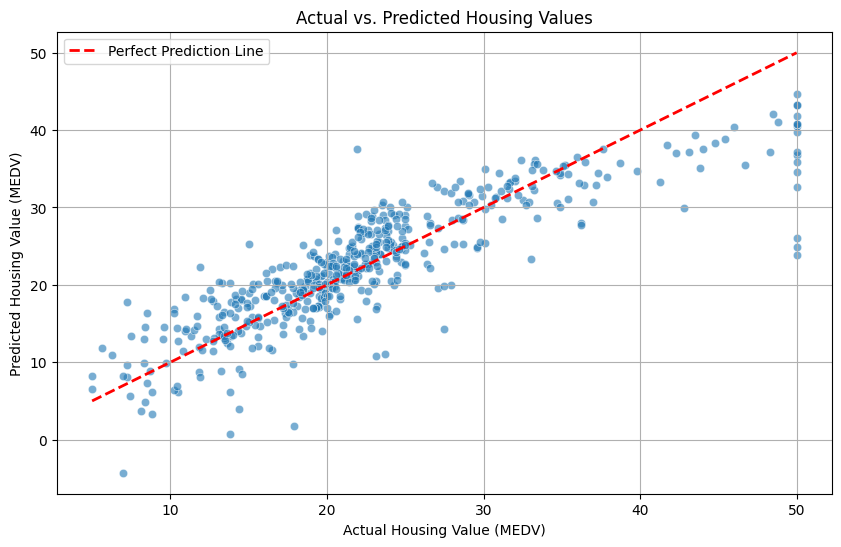

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions
y_pred = model_pipeline.predict(X)

# Create a DataFrame for plotting
predictions_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=predictions_df, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Housing Values')
plt.xlabel('Actual Housing Value (MEDV)')
plt.ylabel('Predicted Housing Value (MEDV)')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# Create the full pipeline with preprocessing and an SVR model
svr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', SVR())])

# Train the SVR model
svr_pipeline.fit(X, y)

# Generate predictions for SVR
y_pred_svr = svr_pipeline.predict(X)

# Calculate and display evaluation metrics for SVR
mae_svr = mean_absolute_error(y, y_pred_svr)
mse_svr = mean_squared_error(y, y_pred_svr)
r2_svr = r2_score(y, y_pred_svr)

print("SVR Model Training Complete.")
print("\nSVR Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"  Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"  R-squared (R2): {r2_svr:.2f}")

SVR Model Training Complete.

SVR Model Performance:
  Mean Absolute Error (MAE): 5.26
  Mean Squared Error (MSE): 66.82
  R-squared (R2): 0.21


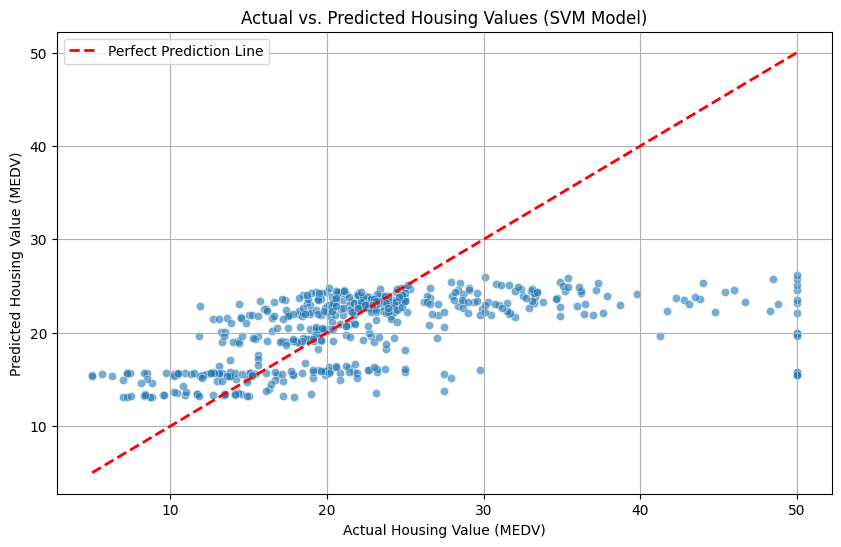

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting SVR predictions
predictions_df_svr = pd.DataFrame({'Actual': y, 'Predicted': y_pred_svr})

# Visualize SVR predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=predictions_df_svr, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Housing Values (SVM Model)')
plt.xlabel('Actual Housing Value (MEDV)')
plt.ylabel('Predicted Housing Value (MEDV)')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
print("\n--- Model Performance Comparison ---")
print("Linear Regression:")
print(f"  MAE: {mae_lr:.2f}")
print(f"  MSE: {mse_lr:.2f}")
print(f"  R2: {r2_lr:.2f}")

print("\nSupport Vector Machine (SVM):")
print(f"  MAE: {mae_svr:.2f}")
print(f"  MSE: {mse_svr:.2f}")
print(f"  R2: {r2_svr:.2f}")


--- Model Performance Comparison ---
Linear Regression:
  MAE: 3.27
  MSE: 21.89
  R2: 0.74

Support Vector Machine (SVM):
  MAE: 5.26
  MSE: 66.82
  R2: 0.21
